## 1. uzdevums. Kursa sintēze: W1–W3 rezultātu apkopojums

## 1.1. Apkopo savus labākos rezultātus

In [8]:
import pandas as pd
import numpy as np

# W1–W3 rezultātu apkopojums
results = pd.DataFrame({
    'Nedēļa': ['W1', 'W2', 'W3', 'W3'],
    'ML uzdevums': ['Klasifikācija', 'Regresija', 'Klasterizācija', 'Validācija'],
    'Labākais modelis': ['Random Forest', 'Lineārā regresija', 'K-Means (K=5)', 'RandomForest'],
    'Galvenā metrika': ['F1 Score', 'R²', 'Inertia', 'CV F1 ± std'],
    'Vērtība': ['0.635', '0.046', '(no Elbow grafika)', '0.635 ± 0.043']
})

print(results.to_string(index=False))

Nedēļa    ML uzdevums  Labākais modelis Galvenā metrika            Vērtība
    W1  Klasifikācija     Random Forest        F1 Score              0.635
    W2      Regresija Lineārā regresija              R²              0.046
    W3 Klasterizācija     K-Means (K=5)         Inertia (no Elbow grafika)
    W3     Validācija      RandomForest     CV F1 ± std      0.635 ± 0.043


## 1.2. Kursa pārskats (Markdown šūna)

Visvieglākā bija regresija, jo grafiki ļoti labi atspoguļo rezultātus un uzreiz redzams cik tālu prognozes atrodas no reālajām vērtībām. Paradoksāli, bet tieši regresijā mans modelis strādāja vissliktāk (R2=0,046). Grūtākā bija klasterizācija un modeļu validācija, jo vienas nedēļas laikā bija jāapgūst daudzi jauni koncepti K-Means, PIPELINE, GridSearchCV utt.Ar vairāk laika katram jēdzienam tēma, iespējams būtu vieglāka. ņemot vērā, ka šo tēmu es mācos no nulles, man šobrīd nav viedokļa ko es macītos savādāk. Priekš manis viegli saprotama bija Inertia, jo Elbow grafikā labi redzams, kur līkne saliecās un kur papildklasteri vairs nedod rezultātu. Data leakage ietekmēja par 0,006 (F1 0,635 VS 0,629) un Pipeline šo risku novērsa. Ar Overfitting saskāros kad testēju lineāro un polinominālo regresiju, polinominālajā regresijā (train test starpība bija 0,097) modelis treniņa datus iemācījās labāk, bet uz reālajiem datiem strādāja sliktāk kā lineārajā regresijā.

## 2. uzdevums. Modeļu un pieeju salīdzinājums

## 2.1. Kādā situācijā lietot kuru pieeju? (Markdown šūna)

Klasifikācija prognozē kategoriju (Jā/Nē, A/B/C) atbilde ir tas vai tas, attiečigi to izvēlētos gadījumos, kad man būtu jāsaklasificē piemēram klienti:Pērk, Nepērk vai kuru auto marku visticamāk nopirks konkrētais klients pamatojoties uz viņa iepriekšējo vēsturi -Hyundai, Nissan, Škoda. Regresija prognozē skaitli (cena, temperatūra, laiks), piemēram rītdienas temperatūra, cik cilvēku šodien atnāks uz veikalu. Klasterizācija = grupēšana (bez zināmas pareizās atbildes, dati paši sevi sadala). Piemēram bibliotēka analizē grāmatu lasīšanas vēsturi un atrod lasītāju tipus: bērnu grāmatu fani, detektīvu mīļotāji, akadēmiskie lasītāji utt.Galvenais šeit, ka kategorijas iepriekš nav zināmas. Cross-validation pārbad parāda, ka modelis stabili strādā ar dažādiem datu apgabaliem, nevis tikai uz viena vairāk vai mazāk veiksmīga. Pipeline nodrošina, ka datu priekšapstrāde (knormalizācija, kodēšana) notiek tikai tikai uz treniņa datiem, nevis visiem datiem kopā un tas novērš leakage, kad modeļa, kad modelis netieši redz testa datus jau treniņa laikā un rezultāts izskatīsies labāks nekā realitātē.

## 2.2. Ja būtu jāizvēlas viens modelis DataShop datiem (Markdown šūna)

Es varu spriest tikai no pārbaudītajiem modeļiem , iespējams izmēģinot citus rezultāti būtu citi. No pārbaudītajiem labākais bija Random Forest ar augstāko F1(atrod visvairāk pircēju) 0.635 ar GridSearchCV uzlabojās līdz 0.653. Tam bija stabils CV 0.635 +/- 0.043 (kas ir maza svārstība). Bet vadībai es atbildētu, ka reāla biznesa situācijā F1 0.65 nav pietiekami augsts rādītājs - modelis joprojām pieļauj daudz kļūdu, pirms tā ieviešanas to būtu jāturpina uzlabot (vairāk datu, citi algoritmi, jaunas pazīmes no esošajiem datiem ).

## 3. uzdevums. Gala projekta plānošana

## 3.2. Uzraksti 4-punktu plānu (Markdown šūna)

**1. Dataset:**
- Bank Marketing Dataset: UCI Machine Learning Repository
- 45 211 rindas × 17 kolonnas 
- Portugāles bankas telefona mārketinga kampaņu dati — banka zvanīja klientiem un piedāvāja termiņdepozītu, fiksējot katra klienta reakciju.

**2. ML problēma:**
- Vai klients piekritīs atvērt termiņdepozītu (yes/no), pamatojoties uz viņa demogrāfisko profilu un iepriekšējo kampaņu rezultātiem.
- Banka var fokusēt zvanus tikai uz visticamākajiem klientiem — ietaupa operatoru laiku, palielina konversiju, samazina kaitinošus zvanus.

**3. ML tipu izvēle:**
- Klasifikācija — target ir binārs (yes/no).

**4. Novērtēšanas metrikas:**
- F1 Score — galvenā metrika, jo dati būs nesabalansēti (lielākā daļa klientu atteiks). F1 parādīs, cik labi modelis atrod tos retos klientus, kas tiešām piekritīs.
- Precision — no tiem, kam modelis teica "piekritīs", cik tiešām piekrita? Svarīgi, lai nesaukam lieki tos, kas teiks "nē".
- Recall — no visiem reālajiem piekritējiem, cik modelis atrada? Svarīgi, lai nepalaižam garām potenciālos klientus.
- Confusion Matrix — vizuāli parāda četrus scenārijus: pareizi atpazīti piekritēji un atteicēji, kā arī abu veidu kļūdas.
- Cross-validation (cv=5) — pārbauda, vai rezultāts ir stabils uz dažādiem datu apgabaliem, nevis tikai uz viena "veiksmīga" splita.

## 4. uzdevums. Datu eksplorācija (EDA) un priekšapstrādes stratēģija

## 4.1. Ielādē un izpēti savus gala projekta datus

In [9]:
#Man Firewall bloķē tiešās ielādes tāpēc šāds apkārtceļš
import urllib.request
import zipfile
import os

os.makedirs('../data', exist_ok=True)

url = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'
zip_path = '../data/bank_marketing.zip'

print("Lejupielādē datus...")
urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('../data/')

with zipfile.ZipFile('../data/bank.zip', 'r') as z:
    z.extractall('../data/')

print("\nFaili data mapē:")
for f in os.listdir('../data/'):
    print(f" - {f}")

Lejupielādē datus...

Faili data mapē:
 - bank-additional.zip
 - bank-full.csv
 - bank-names.txt
 - bank.csv
 - bank.zip
 - bank_marketing.zip


In [10]:
import pandas as pd

df_final = pd.read_csv('../data/bank-full.csv', sep=';')

print(f"Dataseta izmērs: {df_final.shape[0]} rindas, {df_final.shape[1]} kolonnas")
print("\nPirmās 5 rindas:")
print(df_final.head())
print("\nDatu tipi:")
print(df_final.dtypes)
print("\nGalvenā statistika:")
print(df_final.describe())
print("\nMissing values:")
print(df_final.isnull().sum())

Dataseta izmērs: 45211 rindas, 17 kolonnas

Pirmās 5 rindas:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Datu tipi:
age          int64
job            str


In [11]:
#Šo daru jo ir daudz trūkstošo datu un gribu saprast cik tieši
# Target kolonnas sadalījums
print("y vērtību sadalījums:")
print(df_final['y'].value_counts())
print("\nProcentuāli:")
print(df_final['y'].value_counts(normalize=True) * 100)

# Unikālās vērtības kategoriskajās kolonnās
print("\nUnikālās vērtības kategoriskajās kolonnās:")
for col in df_final.select_dtypes(include='object').columns:
    print(f"  {col}: {df_final[col].nunique()} unikālas")

# Cik rindās ir 'unknown'?
print("\n'unknown' vērtību skaits katrā kolonnā:")
for col in df_final.select_dtypes(include='object').columns:
    unknown_count = (df_final[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df_final) * 100
        print(f"  {col}: {unknown_count} ({pct:.1f}%)")

y vērtību sadalījums:
y
no     39922
yes     5289
Name: count, dtype: int64

Procentuāli:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

Unikālās vērtības kategoriskajās kolonnās:
  job: 12 unikālas
  marital: 3 unikālas
  education: 4 unikālas
  default: 2 unikālas
  housing: 2 unikālas
  loan: 2 unikālas
  contact: 3 unikālas
  month: 12 unikālas
  poutcome: 4 unikālas
  y: 2 unikālas

'unknown' vērtību skaits katrā kolonnā:
  job: 288 (0.6%)
  education: 1857 (4.1%)
  contact: 13020 (28.8%)
  poutcome: 36959 (81.7%)


C:\Users\mara.medne\AppData\Local\Temp\ipykernel_23220\2433954556.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_final.select_dtypes(include='object').columns:
C:\Users\mara.medne\AppData\Local\Temp\ipykernel_23220\2433954556.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.or

# Domājot par datu tīrīšanu, redzu, ka ir rindas kurās vienīgais zināmais ir vecums, piemēram, gribu saprast cik tādas ir un kādi ir nezināmie un vai starp tiem ir bijuši klienti un cik daudz.

In [12]:
# Saskaita, cik "unknown" ir katrā rindā
df_final['unknown_count'] = (df_final == 'unknown').sum(axis=1)

print("Cik rindās ir kāds 'unknown':")
print(df_final['unknown_count'].value_counts().sort_index())

Cik rindās ir kāds 'unknown':
unknown_count
0     7842
1    23459
2    13119
3      737
4       54
Name: count, dtype: int64


In [13]:
# Pārbaudām, cik no "smagi unknown" rindām ir depozīta atvērēji (y=yes)
problem_rows = df_final[df_final['unknown_count'] >= 3]

print(f"Kopā rindas ar >=3 'unknown': {len(problem_rows)}")
print(f"\nTajās y sadalījums:")
print(problem_rows['y'].value_counts())

yes_in_problem = (problem_rows['y'] == 'yes').sum()
yes_total = (df_final['y'] == 'yes').sum()
print(f"\nNo visiem 'yes' klientiem ({yes_total}):")
print(f"  >=3 'unknown' rindās: {yes_in_problem} ({yes_in_problem/yes_total*100:.1f}%)")

# Tas pats robežai >=4
print("\n" + "="*50)
problem_rows_4 = df_final[df_final['unknown_count'] >= 4]
print(f"Kopā rindas ar >=4 'unknown': {len(problem_rows_4)}")
print(f"\nTajās y sadalījums:")
print(problem_rows_4['y'].value_counts())

yes_in_problem_4 = (problem_rows_4['y'] == 'yes').sum()
print(f"\nNo visiem 'yes' klientiem ({yes_total}):")
print(f"  >=4 'unknown' rindās: {yes_in_problem_4} ({yes_in_problem_4/yes_total*100:.1f}%)")

# Parādām dažas no šīm rindām
print("\n" + "="*50)
print("Rindu paraugi ar >=3 'unknown' (pirmās 10):")
print(problem_rows.head(10))

Kopā rindas ar >=3 'unknown': 791

Tajās y sadalījums:
y
no     759
yes     32
Name: count, dtype: int64

No visiem 'yes' klientiem (5289):
  >=3 'unknown' rindās: 32 (0.6%)

Kopā rindas ar >=4 'unknown': 54

Tajās y sadalījums:
y
no     53
yes     1
Name: count, dtype: int64

No visiem 'yes' klientiem (5289):
  >=4 'unknown' rindās: 1 (0.0%)

Rindu paraugi ar >=3 'unknown' (pirmās 10):
    age          job  marital education default  balance housing loan  \
3    47  blue-collar  married   unknown      no     1506     yes   no   
4    33      unknown   single   unknown      no        1      no   no   
13   58   technician  married   unknown      no       71     yes   no   
16   45       admin.   single   unknown      no       13     yes   no   
42   60  blue-collar  married   unknown      no      104     yes   no   
44   58      retired  married   unknown      no       96     yes   no   
57   47  blue-collar  married   unknown      no      306     yes   no   
58   40  blue-collar   sin

In [14]:
# Dzēšam rindas ar 4 vai vairāk 'unknown' vērtībām
rindas_pirms = len(df_final)
df_final = df_final[df_final['unknown_count'] < 4].copy()
rindas_pec = len(df_final)

print(f"Rindas pirms: {rindas_pirms}")
print(f"Rindas pēc: {rindas_pec}")
print(f"Izmesti: {rindas_pirms - rindas_pec}")

# Izņemam palīgkolonnu, vairs nevajag
df_final = df_final.drop(columns=['unknown_count'])
print(f"\nKolonnas tagad: {df_final.columns.tolist()}")

# Pārbaudām, ka y sadalījums joprojām labs
print(f"\nY sadalījums pēc tīrīšanas:")
print(df_final['y'].value_counts())


Rindas pirms: 45211
Rindas pēc: 45157
Izmesti: 54

Kolonnas tagad: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Y sadalījums pēc tīrīšanas:
y
no     39869
yes     5288
Name: count, dtype: int64


Skaitliskās kolonnas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


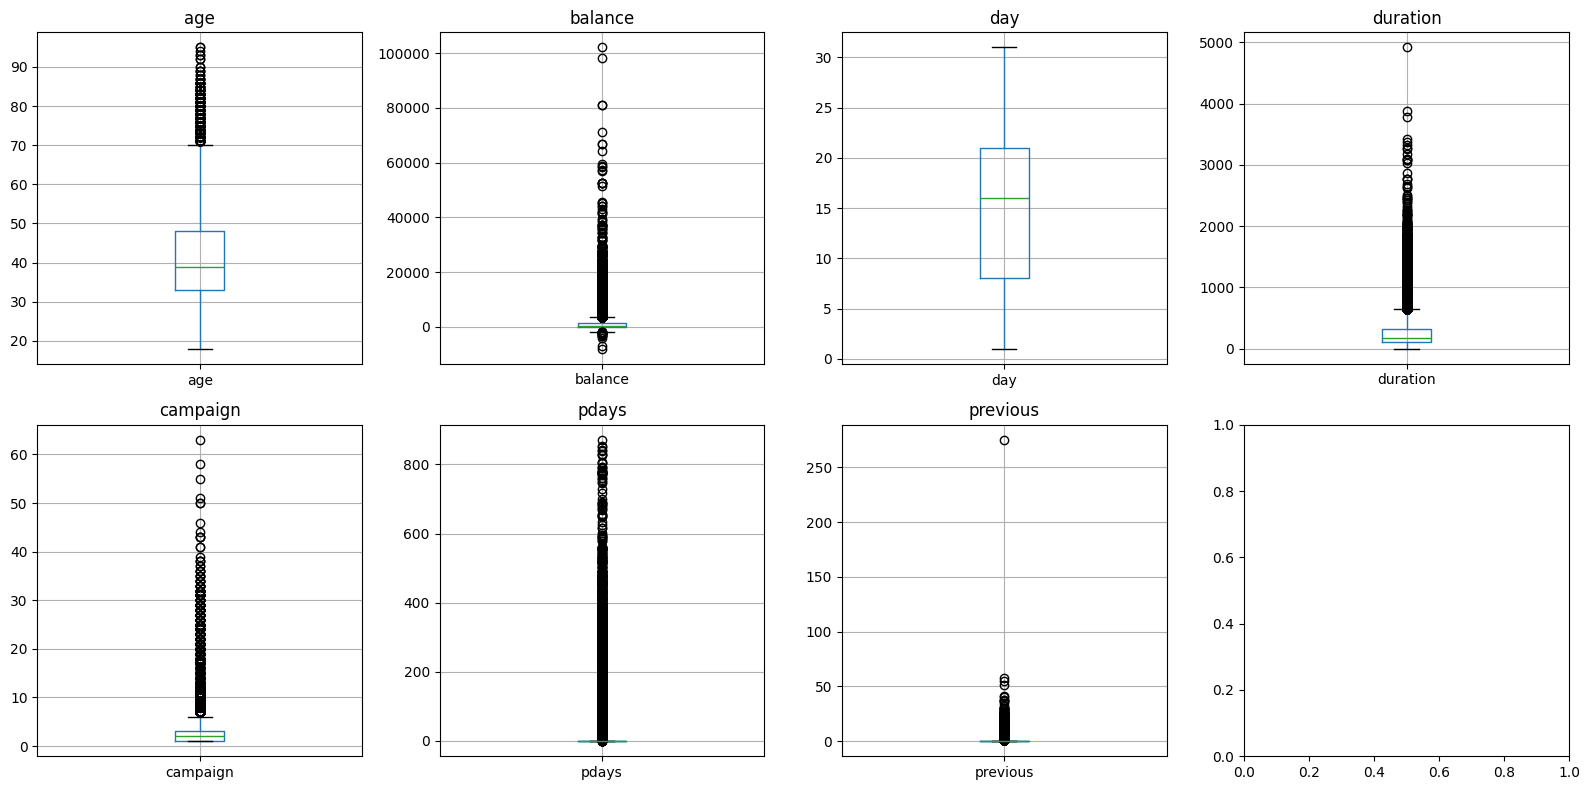


Skaitlisko kolonnu statistika:
                age        balance           day      duration      campaign  \
count  45157.000000   45157.000000  45157.000000  45157.000000  45157.000000   
mean      40.927608    1362.265407     15.809022    258.224218      2.763514   
std       10.618461    3045.167218      8.323981    257.592194      3.098558   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1427.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45157.000000  45157.000000  
mean      40.247093      0.581017  
std      100.178456      2.304730  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.0000

In [15]:
import matplotlib.pyplot as plt

# Izlēcēju pārbaude ar boxplot visām skaitliskām kolonnām
numeric_cols = df_final.select_dtypes(include='int64').columns.tolist()
print(f"Skaitliskās kolonnas: {numeric_cols}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 4, i % 4]
    df_final.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Statistika par izlēcējiem
print("\nSkaitlisko kolonnu statistika:")
print(df_final[numeric_cols].describe())

- Šajā datu setā bija 45 211, no tām bez unknown ir tikai 7842 rindas. Rindas ar vismaz vienu unknown ir 82.7%. Jā ir 54. rindas, tajās ir tikai 1 depozīta atvērējs, uzskatu ka tās ir nevērtīgas un tās labāk ir izdzēst.Vēl būtiski, ka galvenais Unknown daudzums ir kolonās poutcome (81.7%)- un kā unkow ir atzīmēti jaunie klienti, kuriem iepriekšējā sesijā banka nav zvanījusi.Contact (28.8%)- nav precīzi zināms mobilais vai mājas tālrunis. Education (4.1%), job (0.6%).
- Kategoriskās kolonas:
  job: (12 unikālas)
  marital: (3 unikālas)
  education: (4 unikālas)
  default: (2 unikālas)
  housing: (2 unikālas)
  loan: (2 unikālas)
  contact: (3 unikālas)
  month: (12 unikālas)
  poutcome: (4 unikālas)
  y: (2 unikālas)
- Jā target "y" kolonā ir acīmredzams disbalanss 88.3% atteicās no depozīta un tikai 11.7% piekrita. Jā skaitliskajās kolonās ir izlēcēji, piemēram balance max 102127 un min -8019. 

